In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.patches as mpatches
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

%matplotlib inline


In [46]:
data = pd.read_csv("cleaned_data.csv")
data.drop("Unnamed: 0",axis=1,inplace=True)
data.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_category_name,distance,delivery_days,estimated_days,ships_in,review_time,arrival_time,delivery_impression,estimated_del_impression,ship_impression
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,0a8556ac6be836b46b3e89920d59291c,delivered,2018-04-25,2018-04-25 22:15:09,2018-05-02 15:20:00,...,home_construction,845.34,14,27,7,5,OnTime,Fast,Slow,Fast
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,f2c7fc58a9de810828715166c672f10a,delivered,2018-06-26,2018-06-26 11:18:58,2018-06-28 14:18:00,...,auto,23.27,3,20,6,3,OnTime,Fast,Neutral,Fast
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,25b14b69de0b6e184ae6fe2755e478f9,delivered,2017-12-12,2017-12-14 09:52:34,2017-12-15 20:13:22,...,perfumery,27.31,6,23,14,3,OnTime,Fast,Neutral,Neutral
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06,2017-12-06 12:13:20,2017-12-07 20:28:28,...,bed_bath_table,457.50,15,29,6,0,OnTime,Fast,Slow,Fast
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06,2017-12-06 12:13:20,2017-12-07 20:28:28,...,bed_bath_table,457.50,15,29,6,1,OnTime,Fast,Slow,Fast


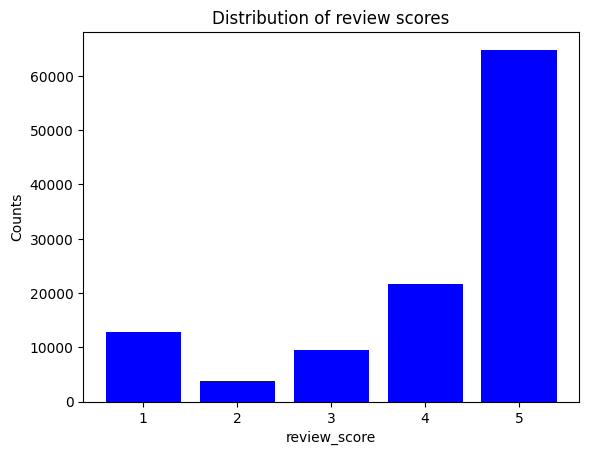

In [47]:
plt.bar(data["review_score"].value_counts().index,data["review_score"].value_counts(),color="blue")
plt.xlabel("review_score")
plt.ylabel("Counts")
plt.title("Distribution of review scores")
plt.show()

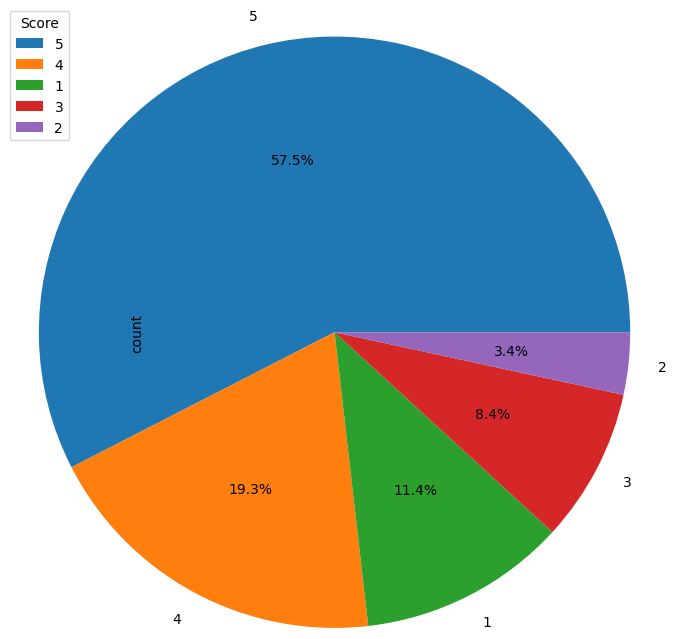

In [48]:
data.review_score.value_counts().plot(kind = 'pie',radius=2,autopct='%.1f%%')
plt.legend(loc= 'lower right', bbox_to_anchor = (-0.2,1), title = 'Score')
plt.show()

In [49]:
numerical_attributes = data[['payment_sequential', 'payment_installments', 'payment_value', 'price', 'freight_value', 
                       'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_width_cm', 'product_length_cm', 'delivery_days', 'estimated_days']]

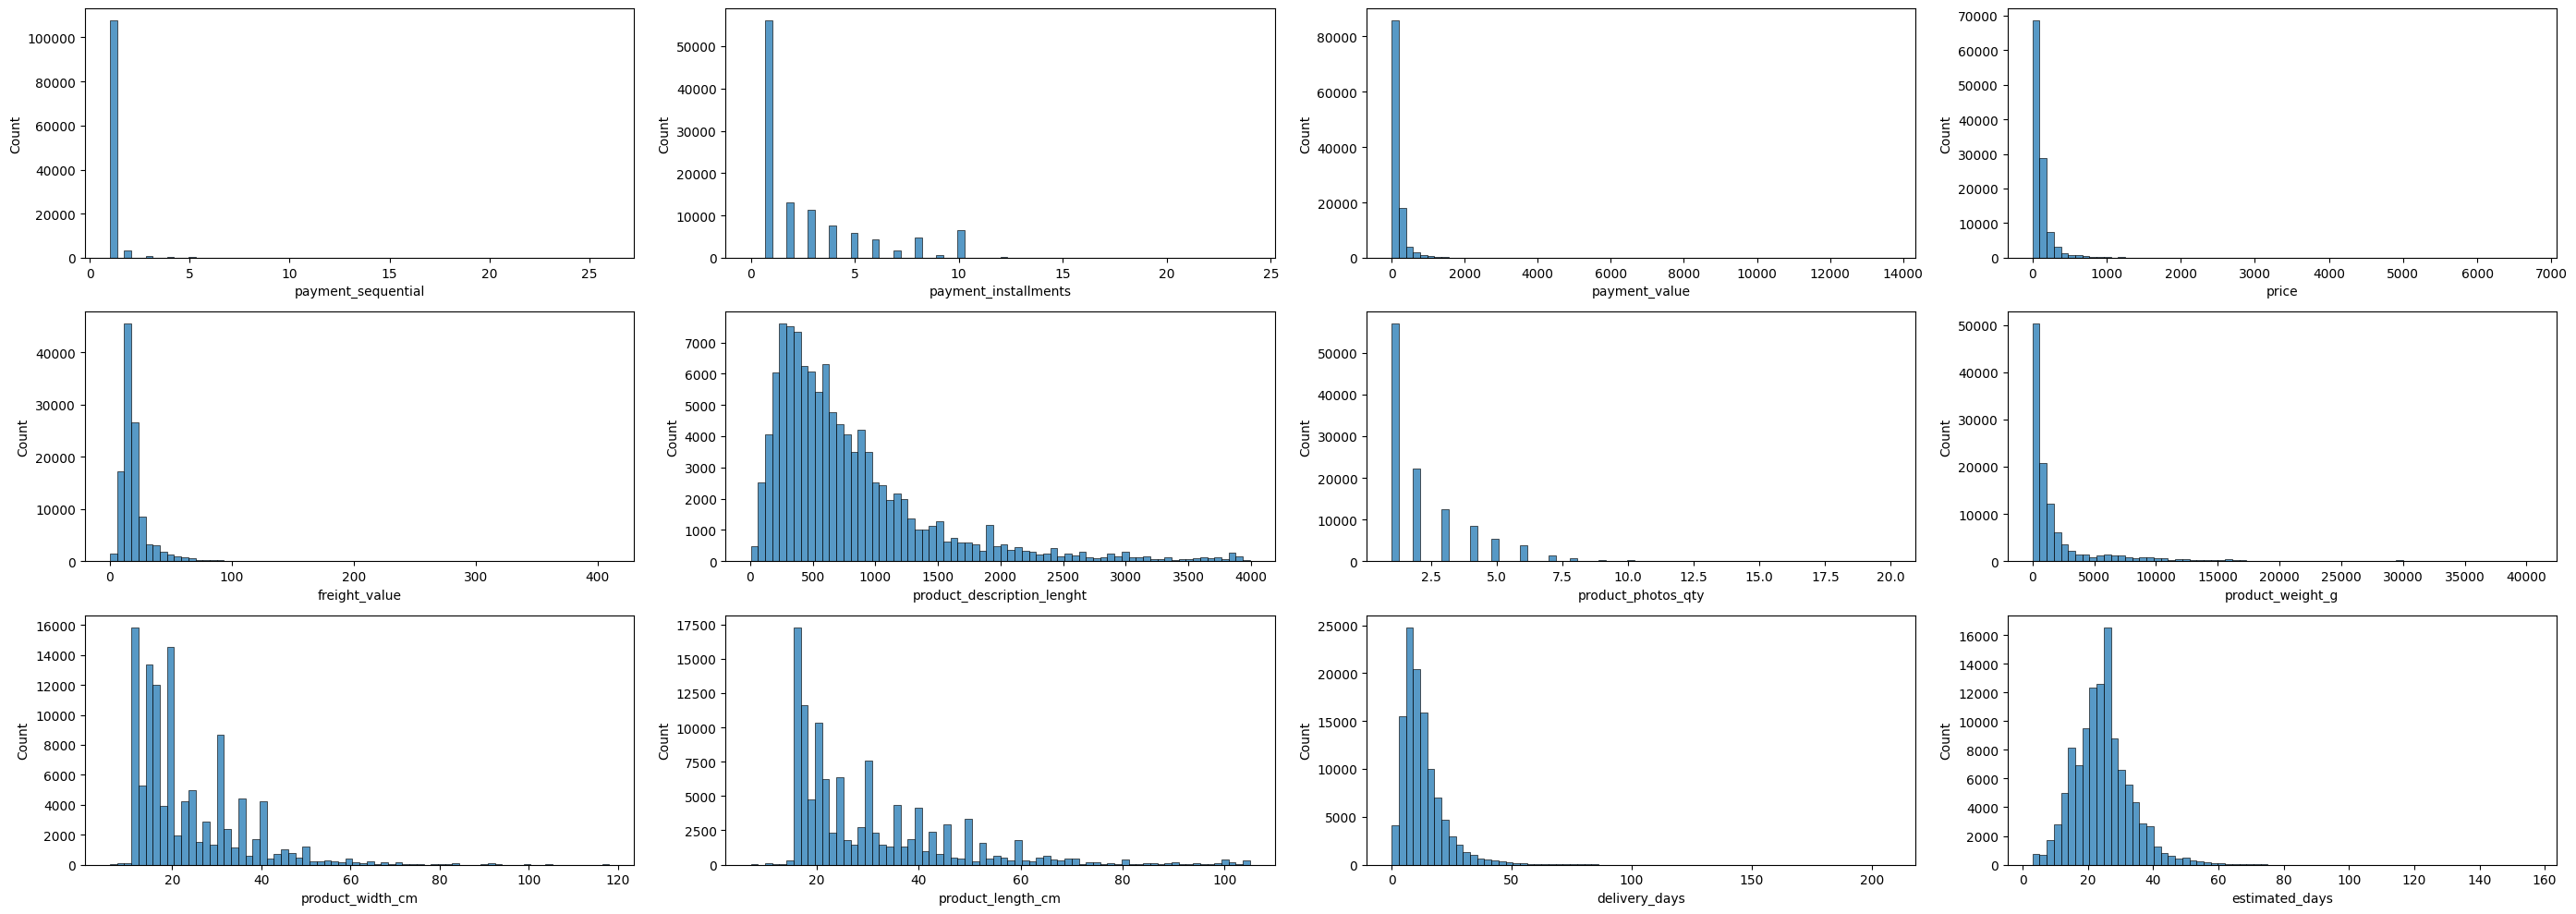

In [50]:
cols = 4
rows = 3
num_cols = numerical_attributes

fig = plt.figure(figsize= (28, 10))
for i, col in enumerate(num_cols):
    ax=fig.add_subplot( rows, cols, i+1)
    sns.histplot(x=numerical_attributes[col], bins=70, ax=ax)
    
fig.tight_layout()  
plt.show()

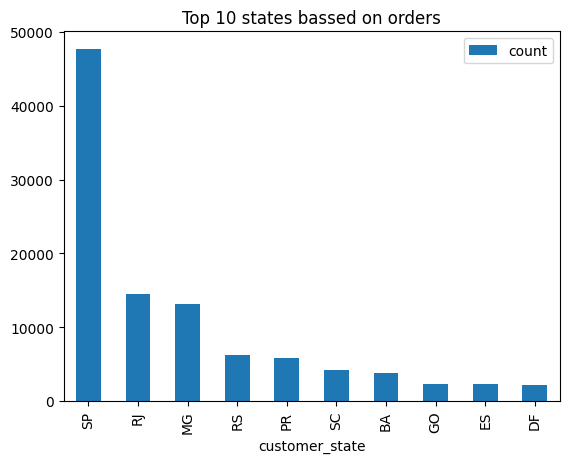

In [51]:
data.customer_state.value_counts()[:10].plot(kind='bar')
plt.legend()
plt.title('Top 10 states bassed on orders')
plt.show()

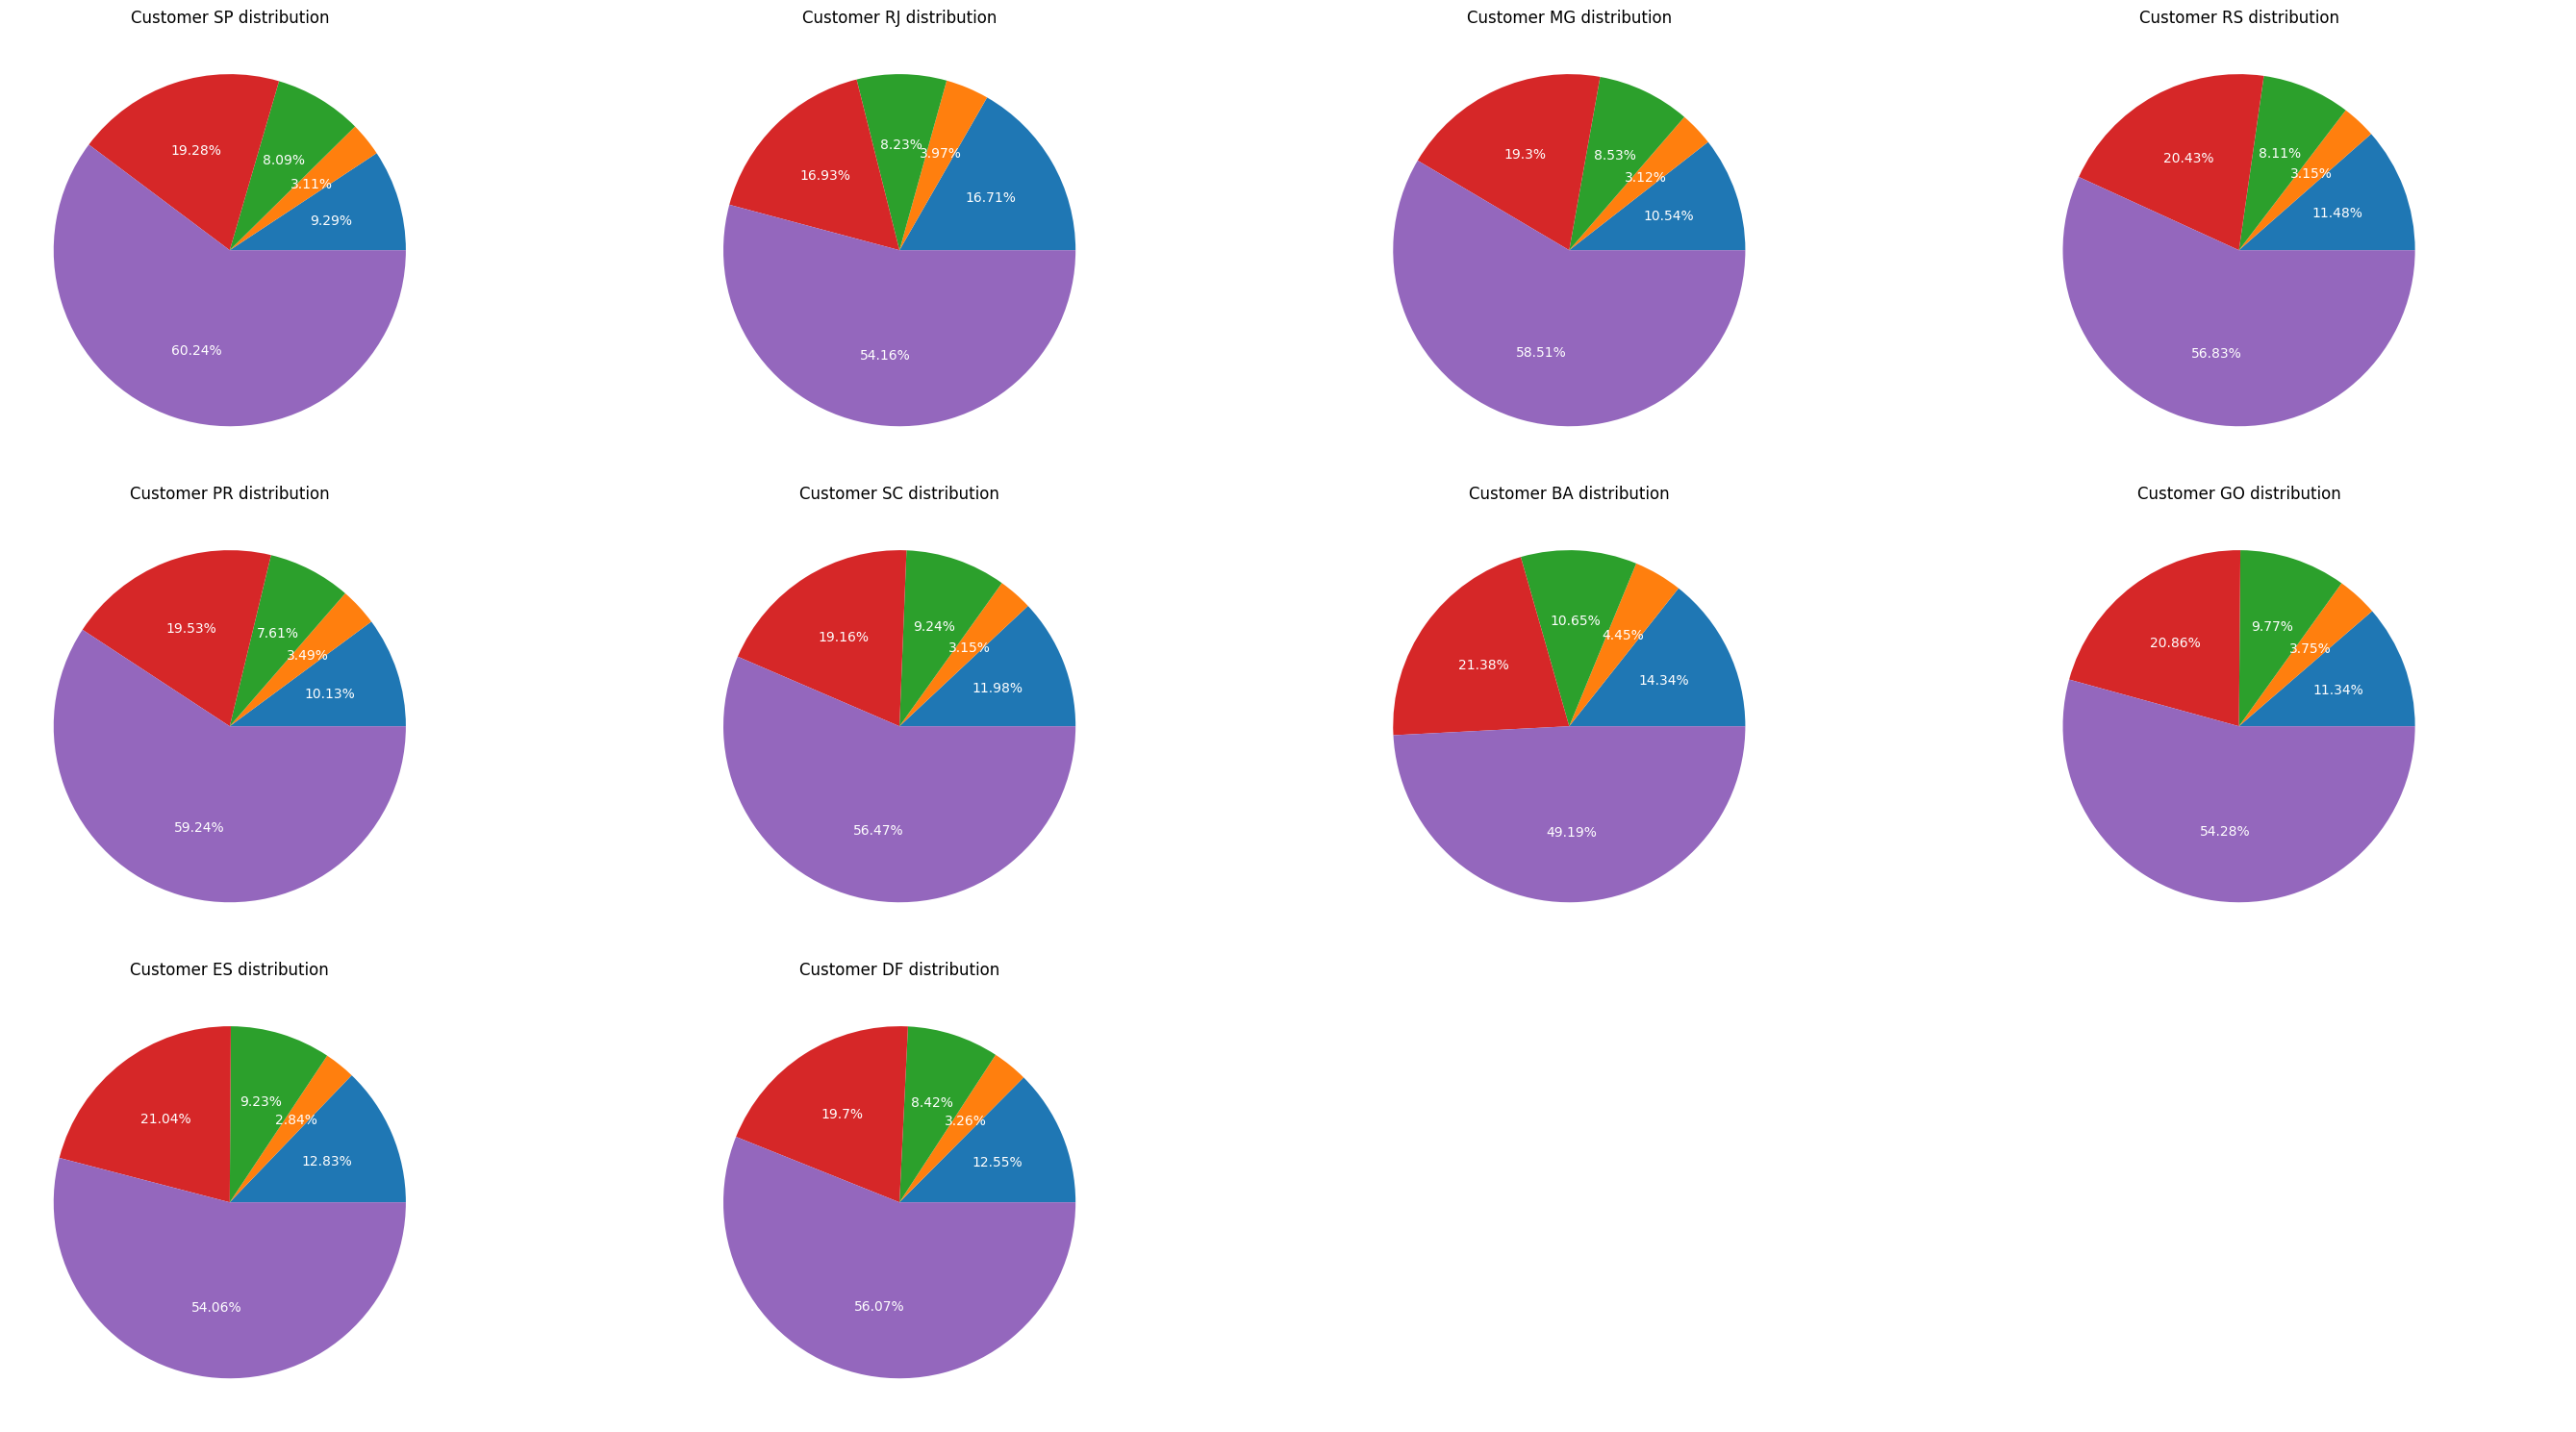

In [52]:
states = ["SP", "RJ", "MG", "RS", "PR", "SC", "BA", "GO", "ES", "DF"]
num_cols = len(states)
cols = 4
rows = -(-num_cols // cols)  # Ceiling division to calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5))

for i, state in enumerate(states):
    row_idx = i // cols
    col_idx = i % cols
    ax = axes[row_idx, col_idx] if rows > 1 else axes[col_idx]

    d = data.groupby("customer_state")["review_score"].value_counts(normalize=True).unstack().loc[state]
    
    ax.pie(d, autopct=lambda pct: str(round(pct, 2)) + "%", textprops=dict(color="w"))
    
    ax.set_title(f"Customer {state} distribution")

# Hide any unused subplots
for i in range(num_cols, rows * cols):
    row_idx = i // cols
    col_idx = i % cols
    axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()


In [53]:
#Top 10 cities bassed on orders
data.customer_city.value_counts().sort_values(ascending=False)[:10]

customer_city
sao paulo                17827
rio de janeiro            7753
belo horizonte            3130
brasilia                  2193
curitiba                  1763
campinas                  1674
porto alegre              1586
salvador                  1417
guarulhos                 1333
sao bernardo do campo     1076
Name: count, dtype: int64

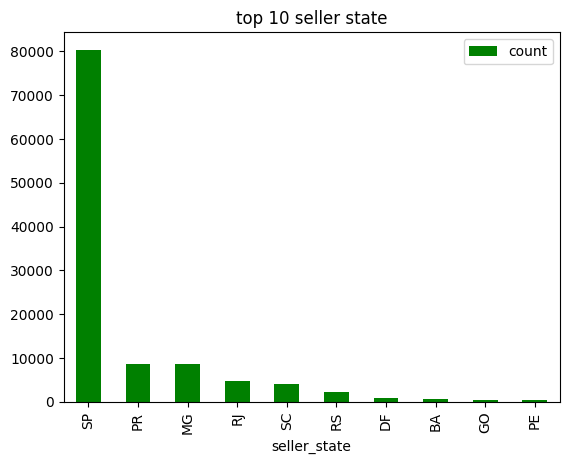

In [54]:
data.seller_state.value_counts().sort_values(ascending=False)[:10].plot(kind='bar',color='g')
plt.legend()
plt.title('top 10 seller state')
plt.show()

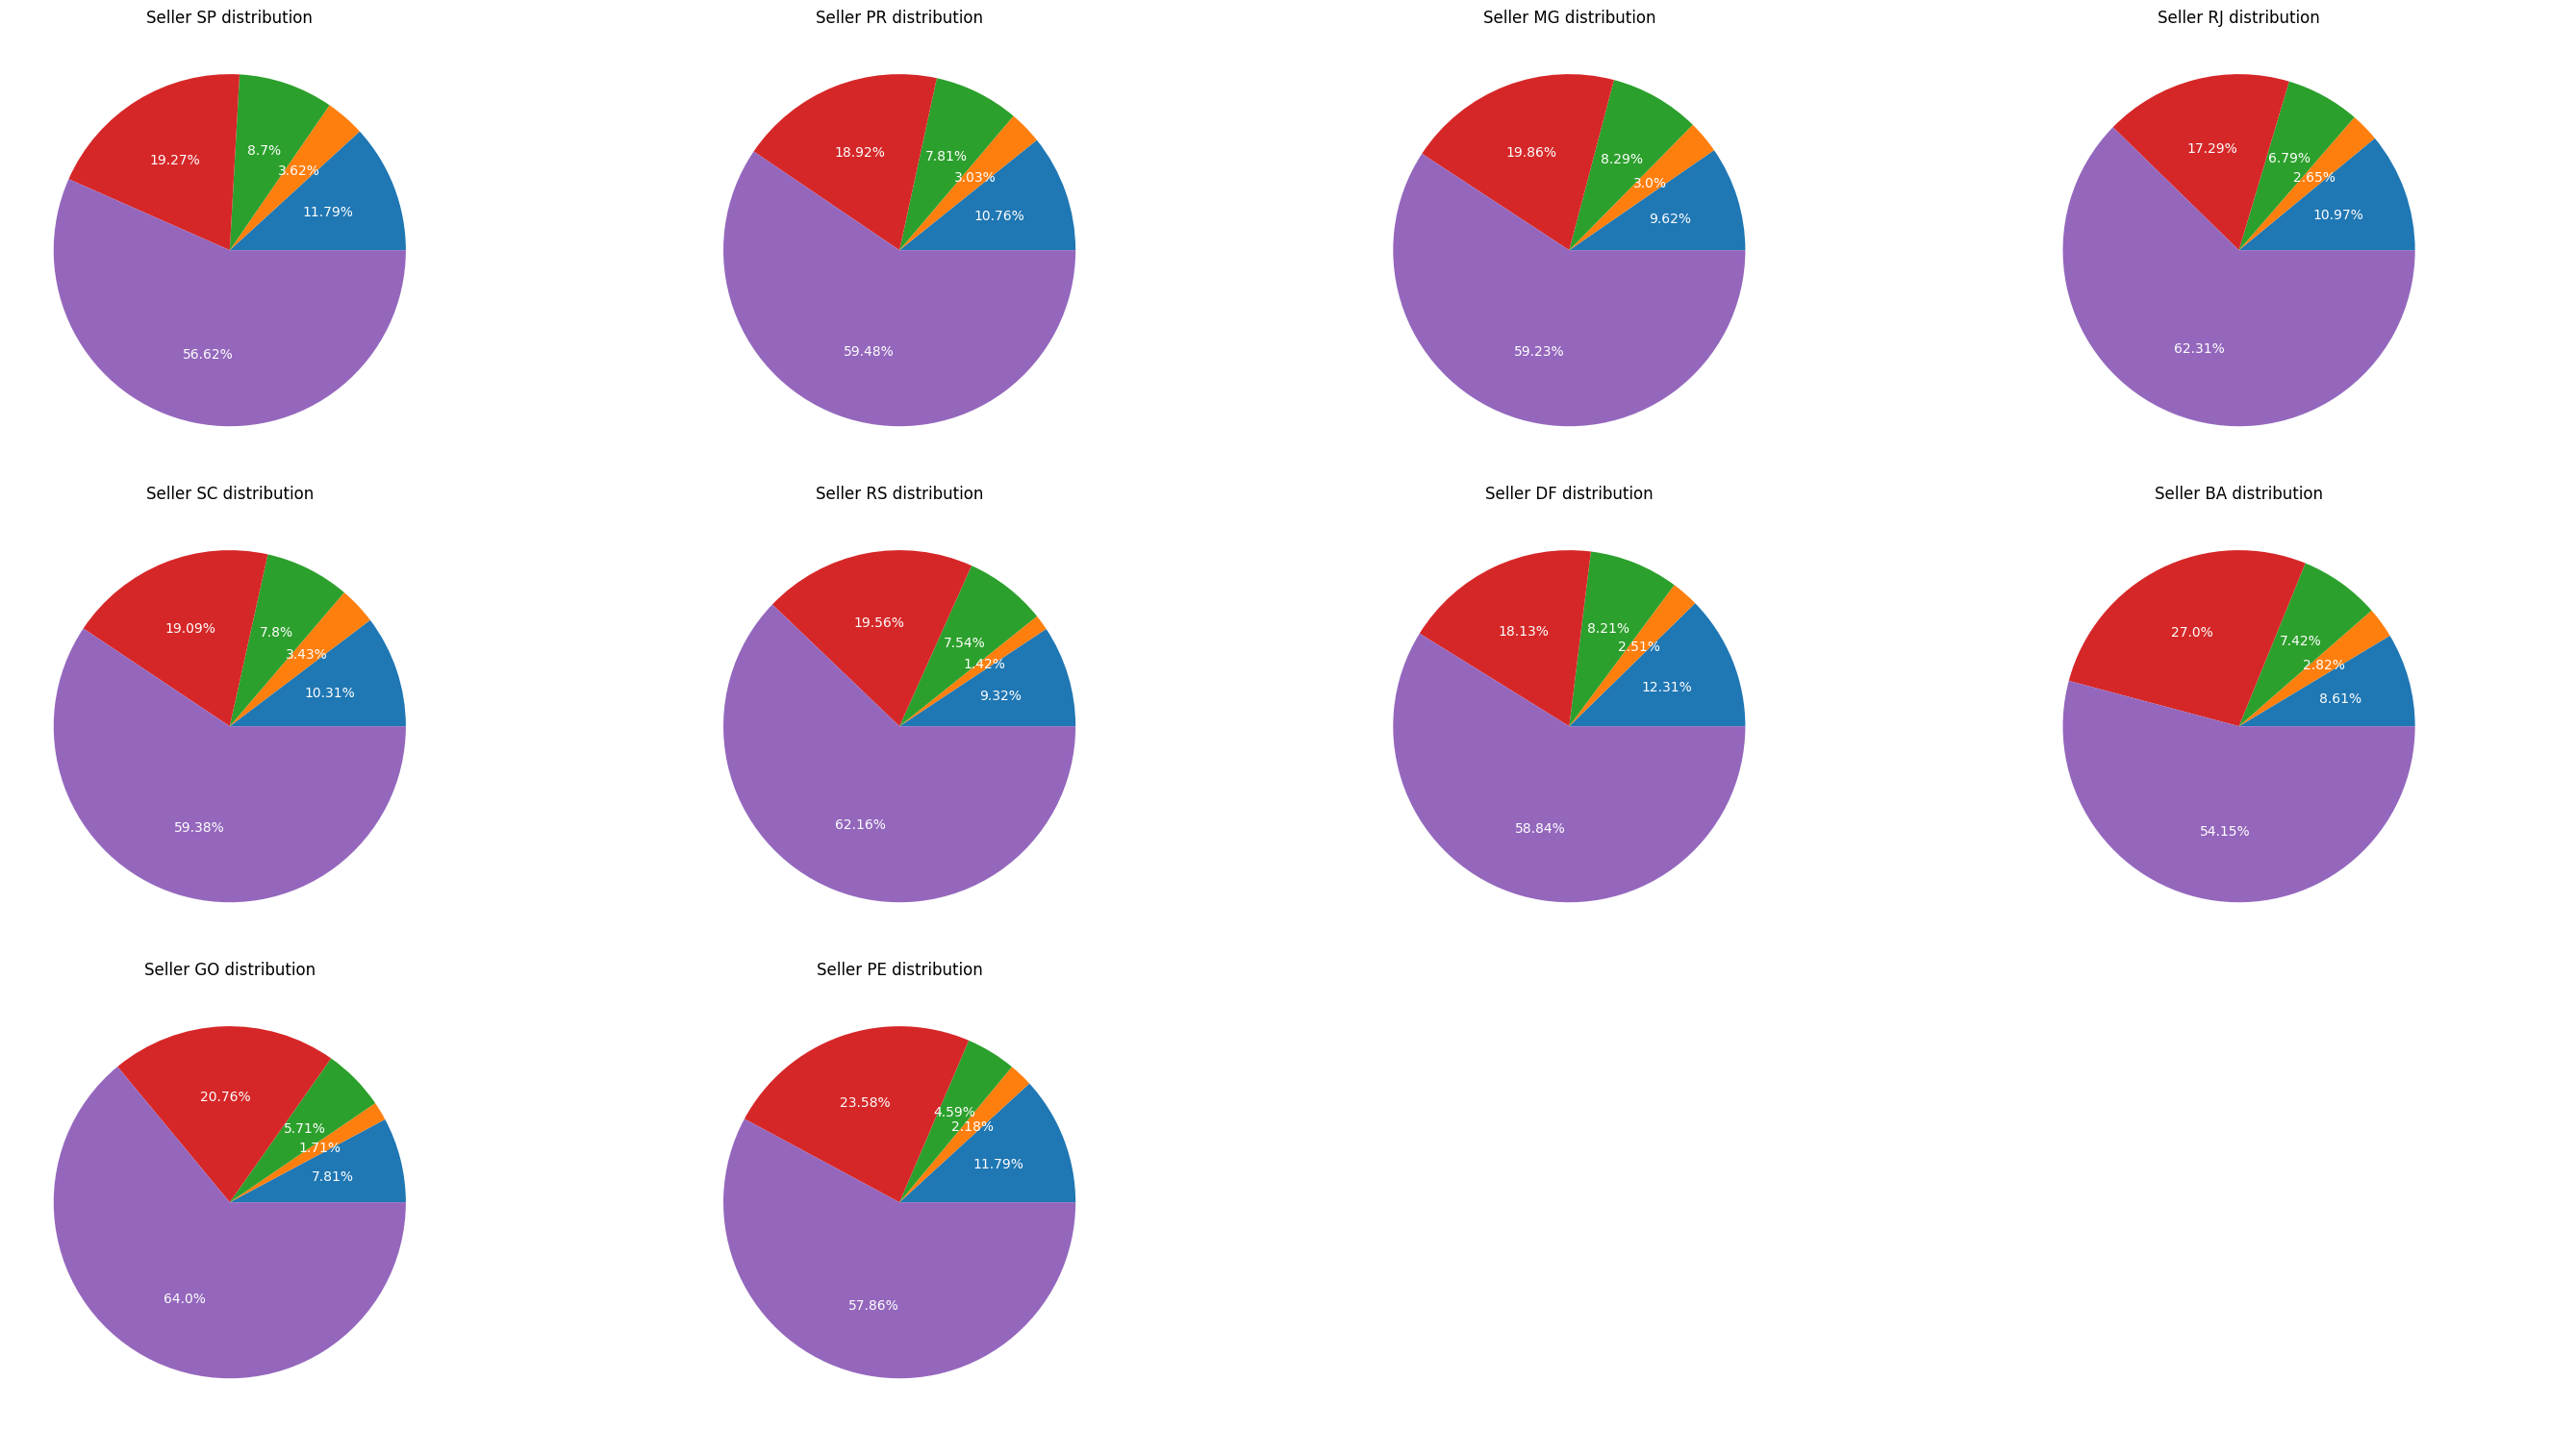

In [55]:
states = ["SP", "PR", "MG", "RJ", "SC", "RS", "DF", "BA", "GO", "PE"]
num_cols = len(states)
cols = 4
rows = -(-num_cols // cols)  # Ceiling division to calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5))

for i, state in enumerate(states):
    row_idx = i // cols
    col_idx = i % cols
    ax = axes[row_idx, col_idx] if rows > 1 else axes[col_idx]

    d = data.groupby("seller_state")["review_score"].value_counts(normalize=True).unstack().loc[state]
    
    ax.pie(d, autopct=lambda pct: str(round(pct, 2)) + "%", textprops=dict(color="w"))
    
    ax.set_title(f"Seller {state} distribution")

# Hide any unused subplots
for i in range(num_cols, rows * cols):
    row_idx = i // cols
    col_idx = i % cols
    axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()


In [56]:
# order item description
data.price.describe()

count    112630.000000
mean        119.876302
std         181.270895
min           0.850000
25%          39.900000
50%          74.900000
75%         133.000000
max        6735.000000
Name: price, dtype: float64

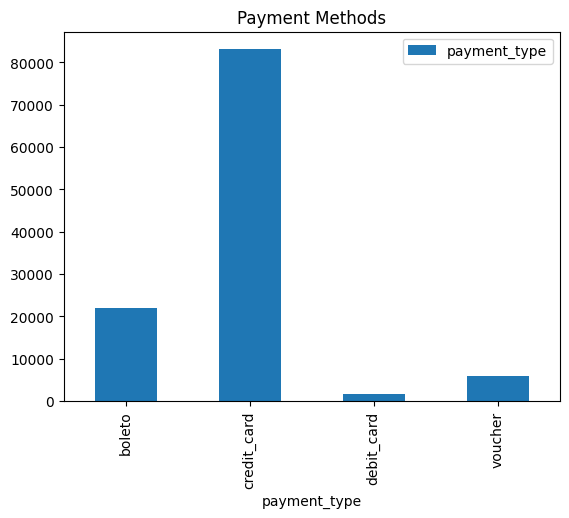

In [57]:
#Most used Payment method for orders
data['payment_type'].groupby(data['payment_type']).count().plot(kind='bar')
plt.legend(loc = 'upper right')
plt.title('Payment Methods')
plt.show()

In [58]:
#payment_type grouped by review_score
pay_type_score = data.groupby("review_score")["payment_type"].value_counts(normalize=True)
pay_type_score.unstack()

payment_type,boleto,credit_card,debit_card,voucher
review_score,,,,
1,0.194876,0.740373,0.011325,0.053425
2,0.184837,0.735948,0.013333,0.065882
3,0.203270,0.729852,0.012869,0.054008
4,0.198019,0.736052,0.013776,0.052154
5,0.192743,0.739019,0.015443,0.052795


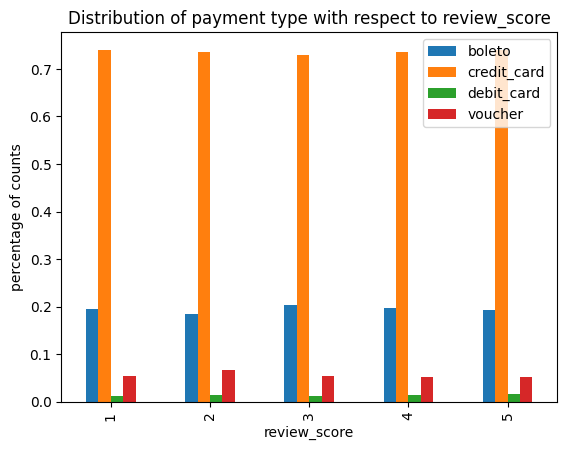

In [59]:
pay_type_score.unstack().plot.bar().legend(loc="best")
plt.ylabel("percentage of counts")
plt.title("Distribution of payment type with respect to review_score")
plt.show()

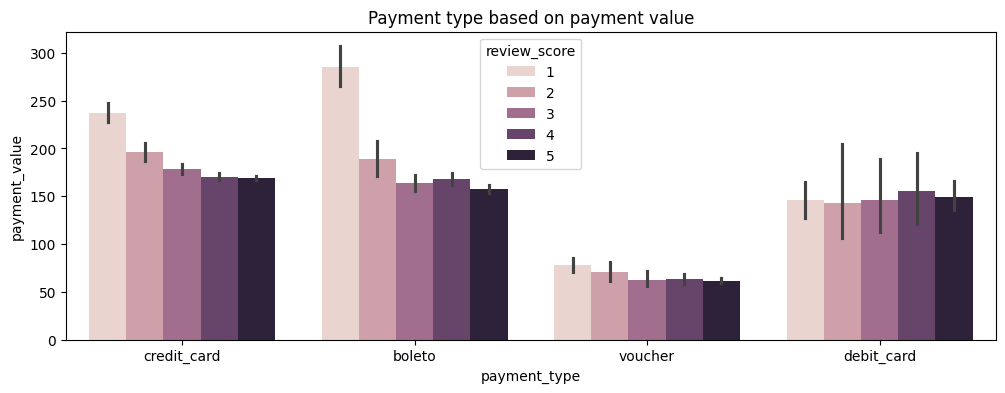

In [60]:
plt.figure(figsize=(12, 4))
plt.title("Payment type based on payment value")
sns.barplot(x = 'payment_type', y = 'payment_value', hue='review_score', data=data);

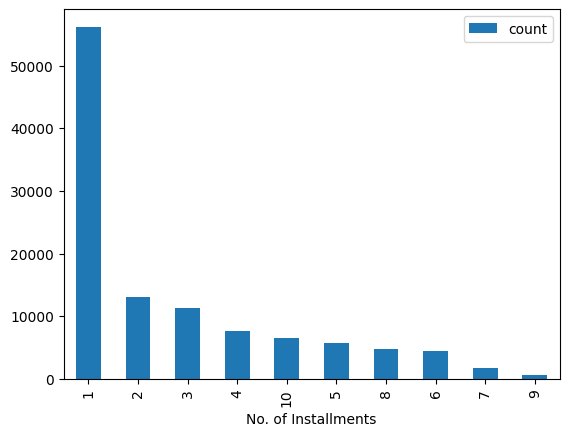

In [61]:
data.payment_installments.value_counts()[:10].plot(kind = 'bar')
plt.legend()
plt.xlabel('No. of Installments')
plt.show()

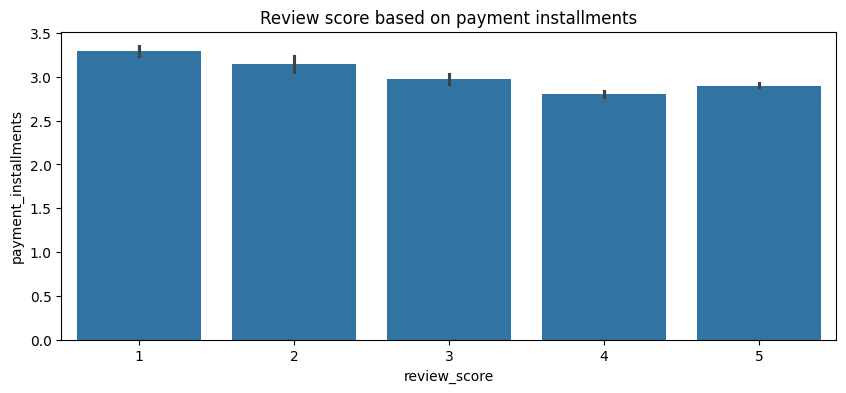

In [62]:
plt.figure(figsize=(10, 4))
plt.title("Review score based on payment installments")
sns.barplot(y='payment_installments', x='review_score', data=data);

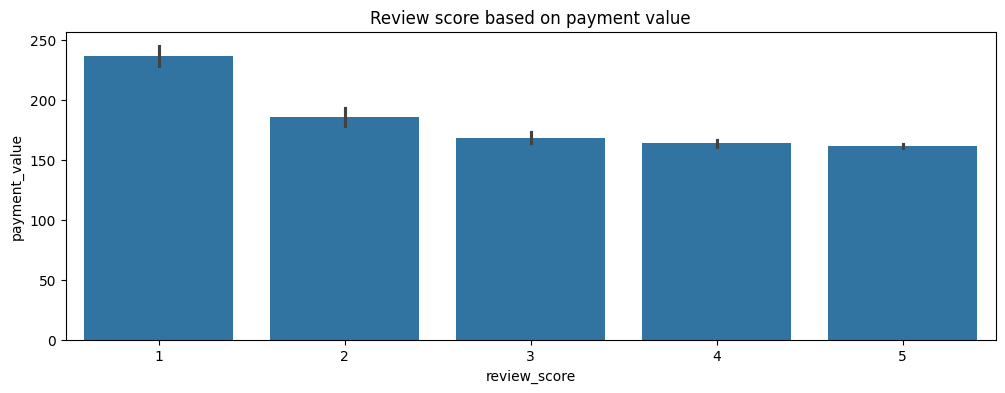

In [63]:
plt.figure(figsize=(12, 4))
plt.title("Review score based on payment value")
sns.barplot(x = 'review_score', y = 'payment_value', data=data);

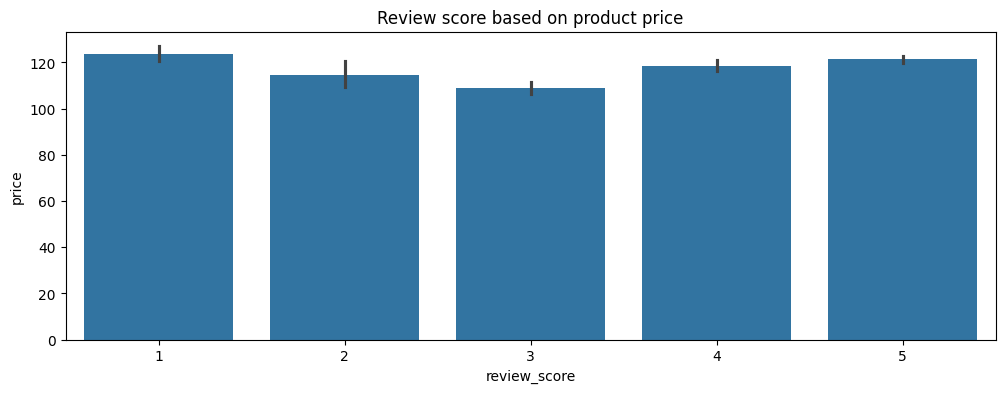

In [64]:
plt.figure(figsize=(12, 4))
plt.title("Review score based on product price")
sns.barplot(x = 'review_score', y = 'price', data=data);

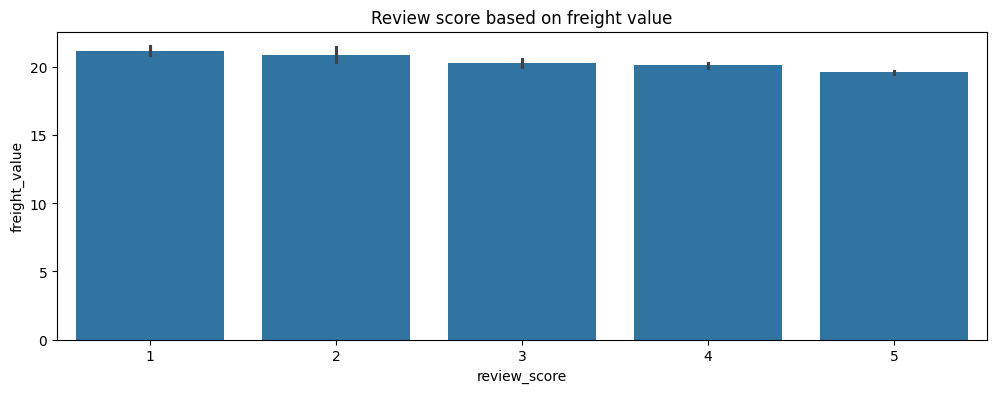

In [65]:
plt.figure(figsize=(12, 4))
plt.title("Review score based on freight value")
sns.barplot(x = 'review_score', y = 'freight_value', data=data);

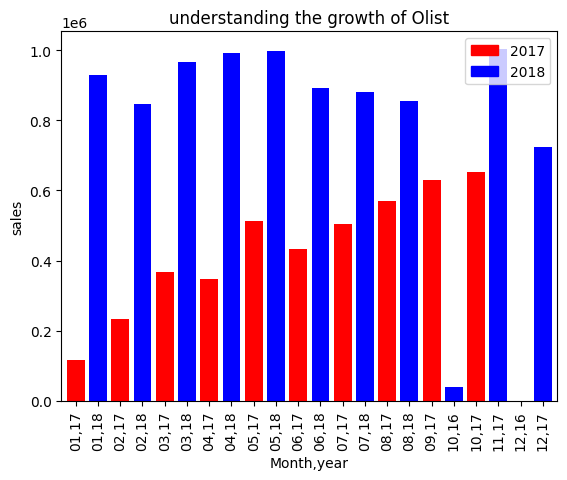

In [66]:
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
monthly_sales_data = data.groupby(data['order_purchase_timestamp'].dt.strftime('%m,%y'))['price'].sum().plot(kind='bar',color=['r','b'],width=0.8)
plt.ylabel('sales')

red_patch = mpatches.Patch(color='red', label='2017')
green_patch = mpatches.Patch(color='blue', label='2018')
plt.legend(handles=[red_patch,green_patch])
plt.xlabel('Month,year')
plt.title('understanding the growth of Olist')
plt.show()

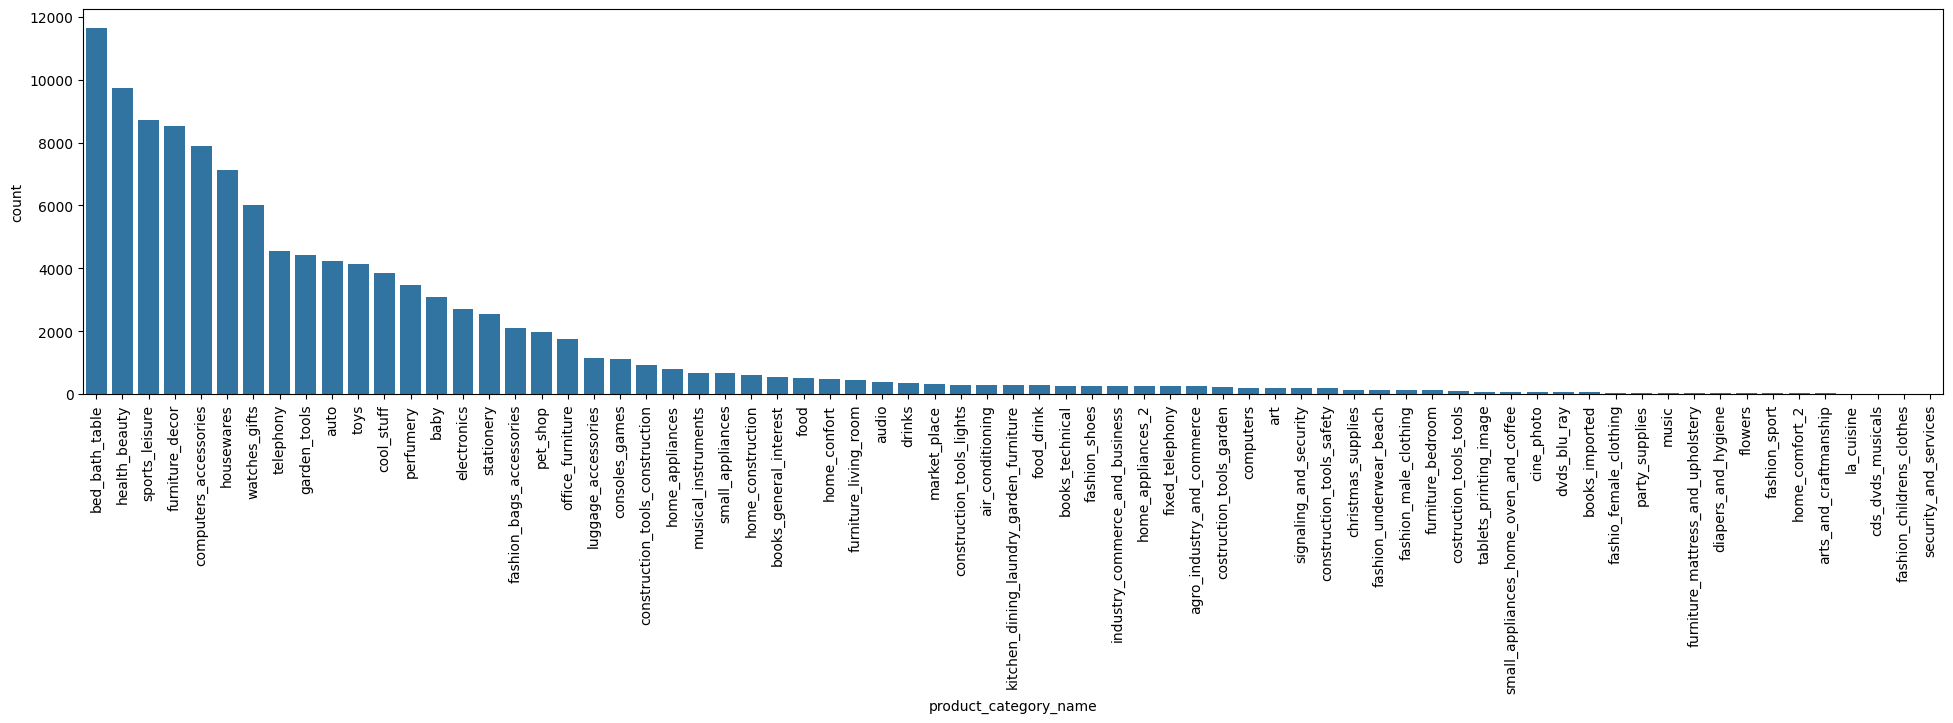

In [67]:
plt.figure(figsize= (24, 5))
sns.barplot(x=data['product_category_name'].value_counts().index,
            y=data['product_category_name'].value_counts())
plt.xticks(rotation=90);

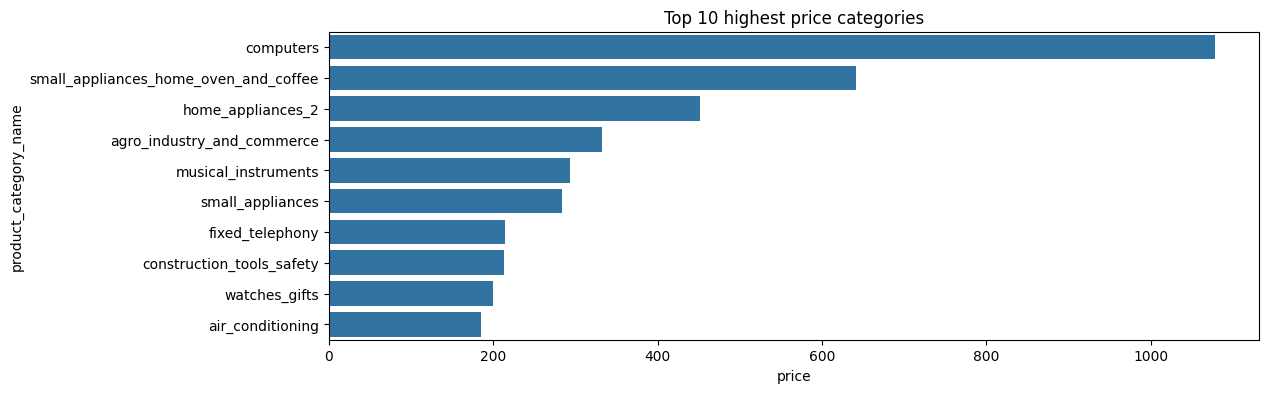

In [68]:
aux = data[['product_category_name', 'price']].groupby('product_category_name').mean().sort_values('price', ascending=False).reset_index()[:10]
plt.figure(figsize=(12, 4))
plt.title('Top 10 highest price categories')
sns.barplot(y='product_category_name', x='price', data=aux);

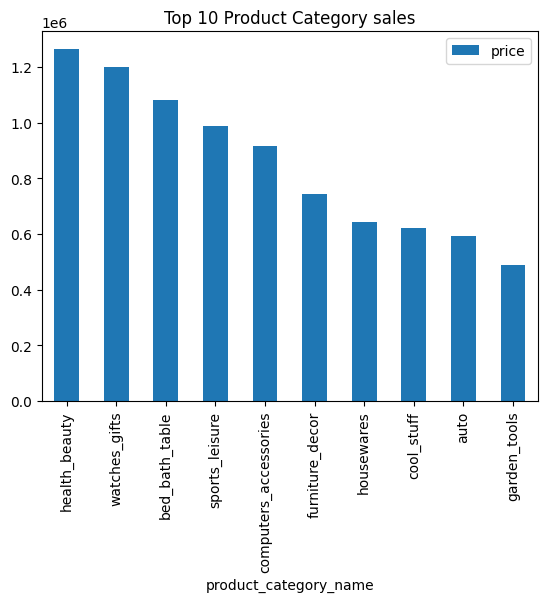

In [69]:
data.groupby(data['product_category_name'])['price'].sum().sort_values(ascending=False)[:10].plot(kind='bar')
plt.legend()
plt.title('Top 10 Product Category sales')
plt.show()

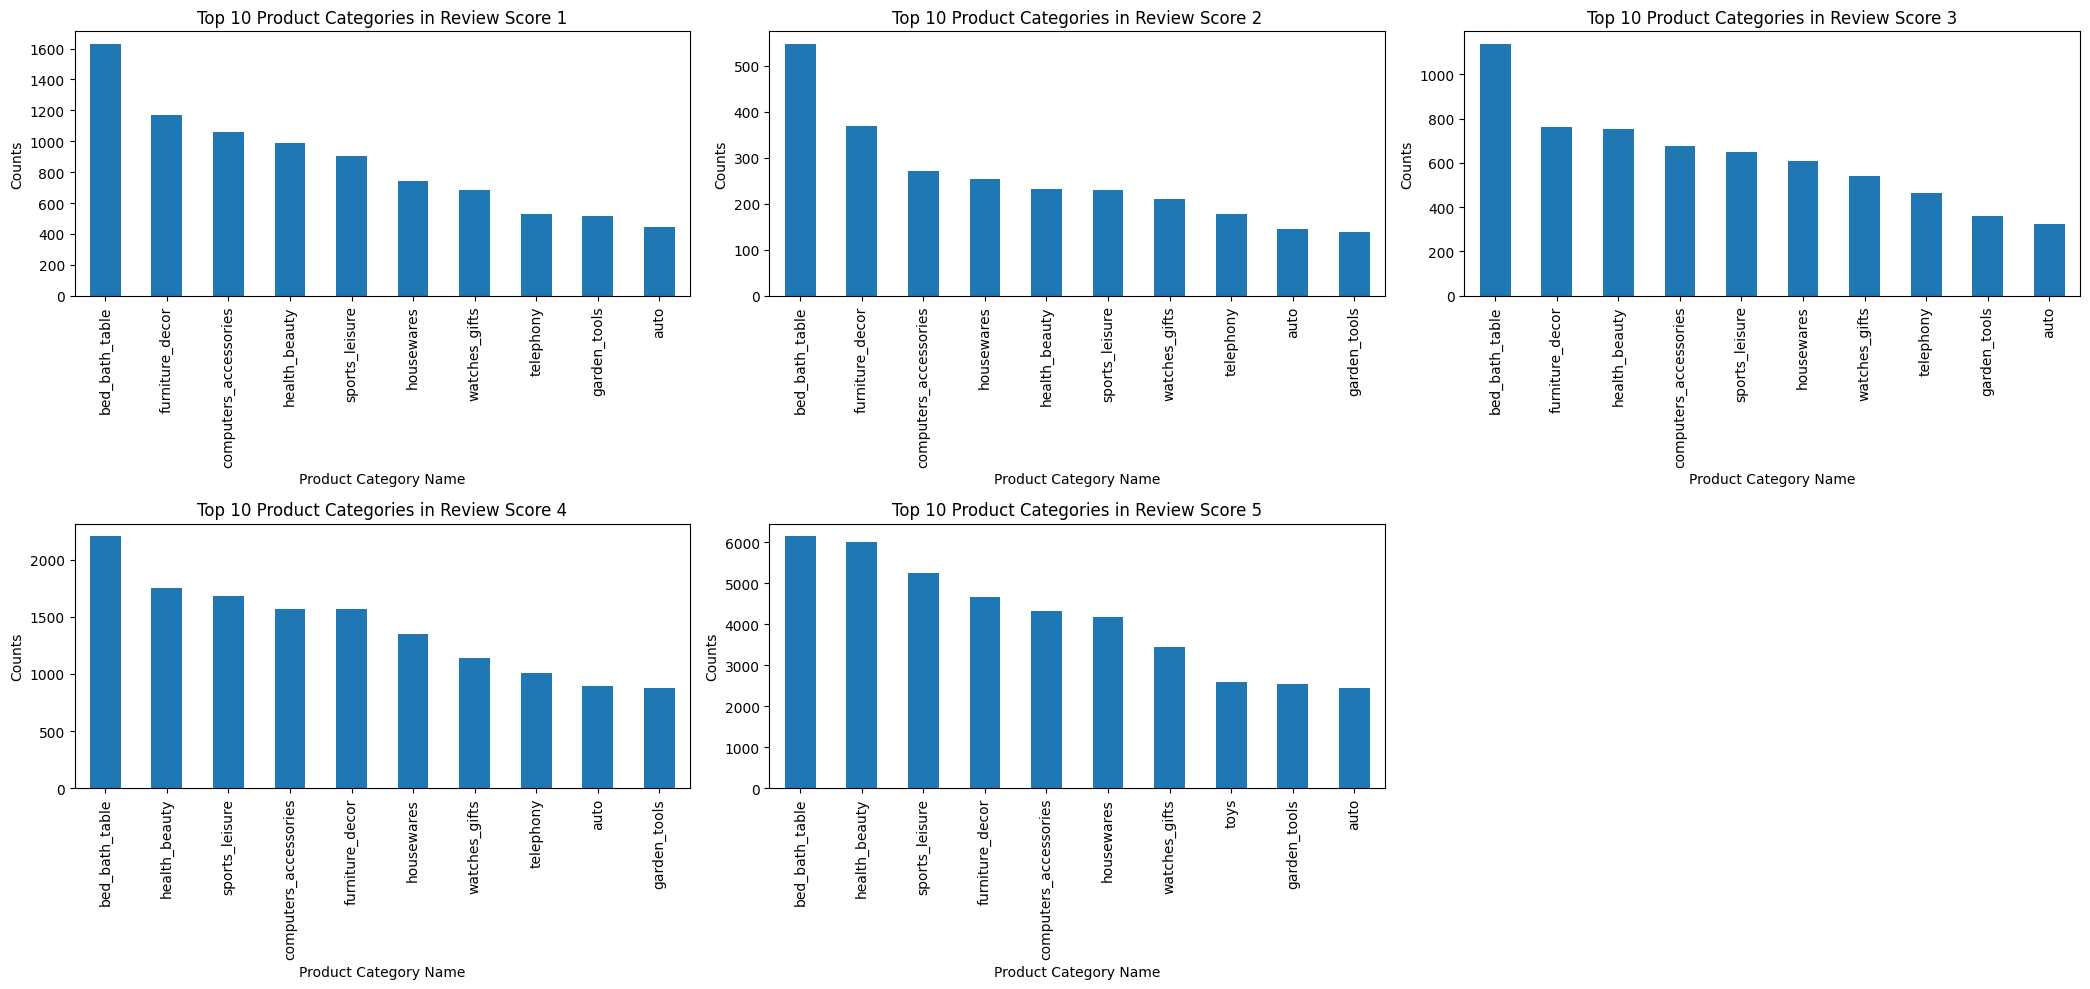

In [70]:
# Define review score values
review_scores = [1, 2, 3, 4, 5]

# Define the number of columns and rows for the grid layout
cols = 3
rows = -(-len(review_scores) // cols)  # Ceiling division to calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 5))

for i, score in enumerate(review_scores):
    row_idx = i // cols
    col_idx = i % cols
    ax = axes[row_idx, col_idx] if rows > 1 else axes[col_idx]

    # Filter data for the current review score
    score_data = data[data["review_score"] == score]
    top_categories = score_data["product_category_name"].value_counts()[:10]

    # Plot bar chart
    top_categories.plot.bar(ax=ax, legend=False)
    ax.set_xlabel("Product Category Name")
    ax.set_ylabel("Counts")
    ax.set_title(f"Top 10 Product Categories in Review Score {score}")

# Hide any unused subplots
for i in range(len(review_scores), rows * cols):
    row_idx = i // cols
    col_idx = i % cols
    axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

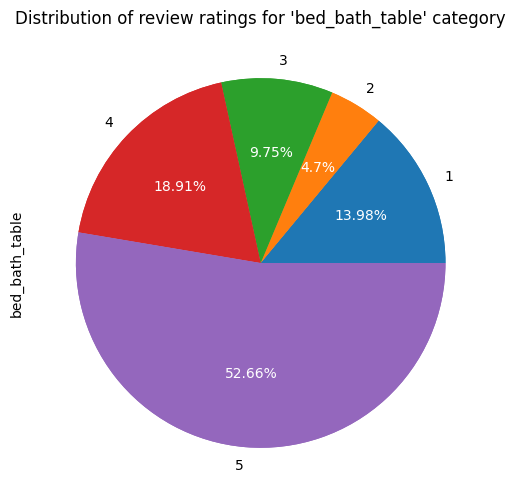

In [71]:
plt.figure(figsize=(6,6))
ax = data.groupby("product_category_name")["review_score"].value_counts(normalize=True).unstack().loc["bed_bath_table"].plot(kind="pie")

d = data.groupby("product_category_name")["review_score"].value_counts(normalize=True).unstack().loc["bed_bath_table"]

wedges, texts, autotexts = ax.pie(d, autopct=lambda pct: str(round(pct,2))+"%",
                                  textprops=dict(color="w"))

plt.title("Distribution of review ratings for 'bed_bath_table' category")
plt.show()

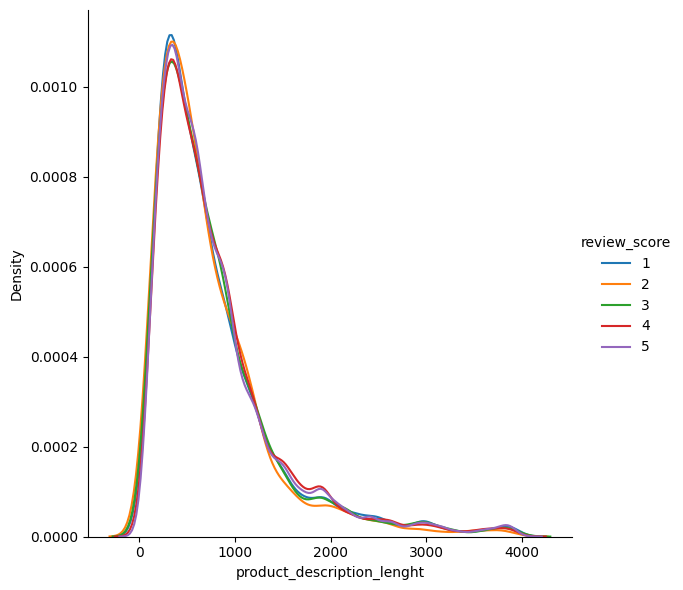

In [72]:
sns.FacetGrid(data,hue="review_score",height=6)\
    .map(sns.kdeplot,"product_description_lenght")\
    .add_legend()
plt.show()

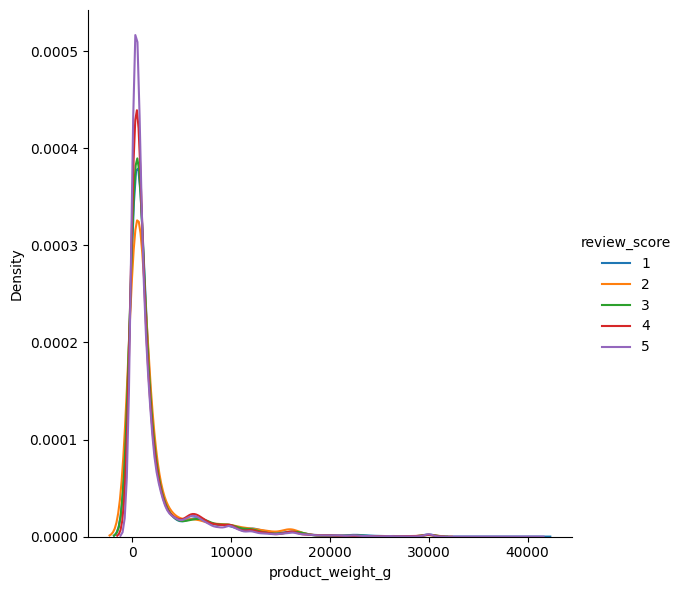

In [73]:
sns.FacetGrid(data,hue="review_score",height=6)\
    .map(sns.kdeplot,"product_weight_g")\
    .add_legend()
plt.show()

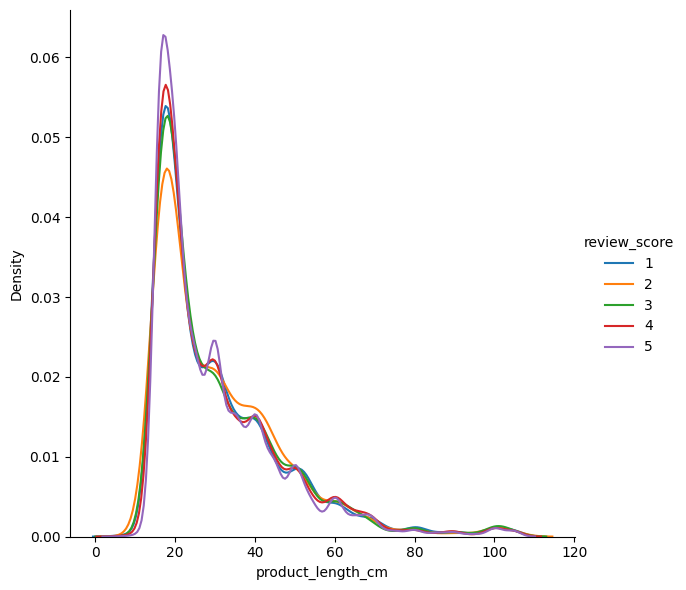

In [74]:
sns.FacetGrid(data,hue="review_score",height=6)\
    .map(sns.kdeplot,"product_length_cm")\
    .add_legend()
plt.show()

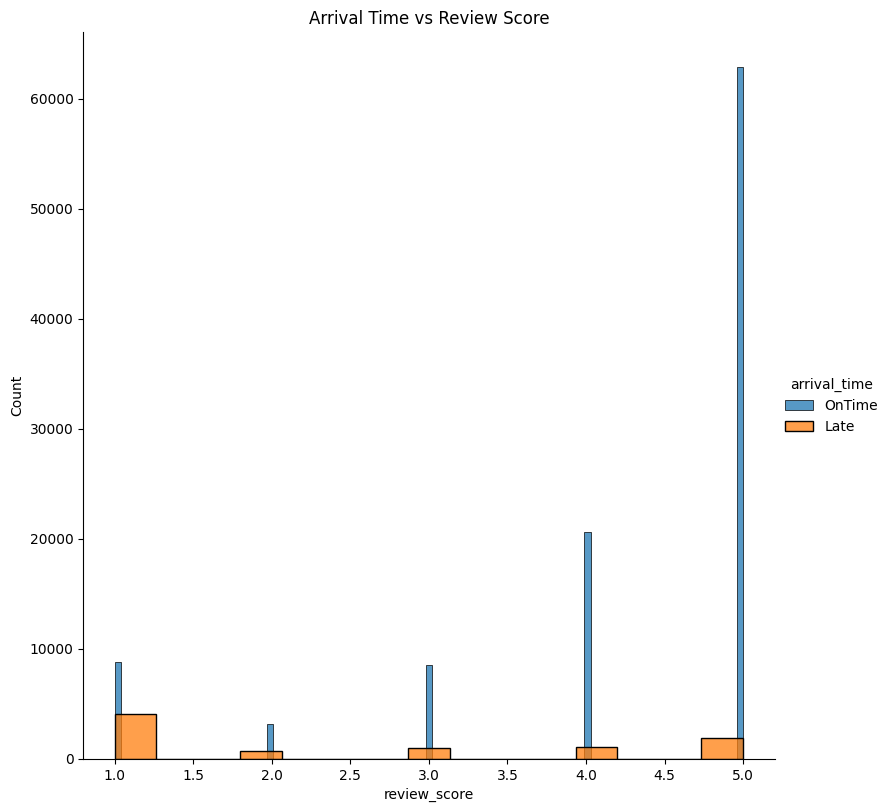

In [75]:
sns.FacetGrid(data, hue='arrival_time', height=8).map(sns.histplot, 'review_score').add_legend()
plt.title('Arrival Time vs Review Score')
plt.show()

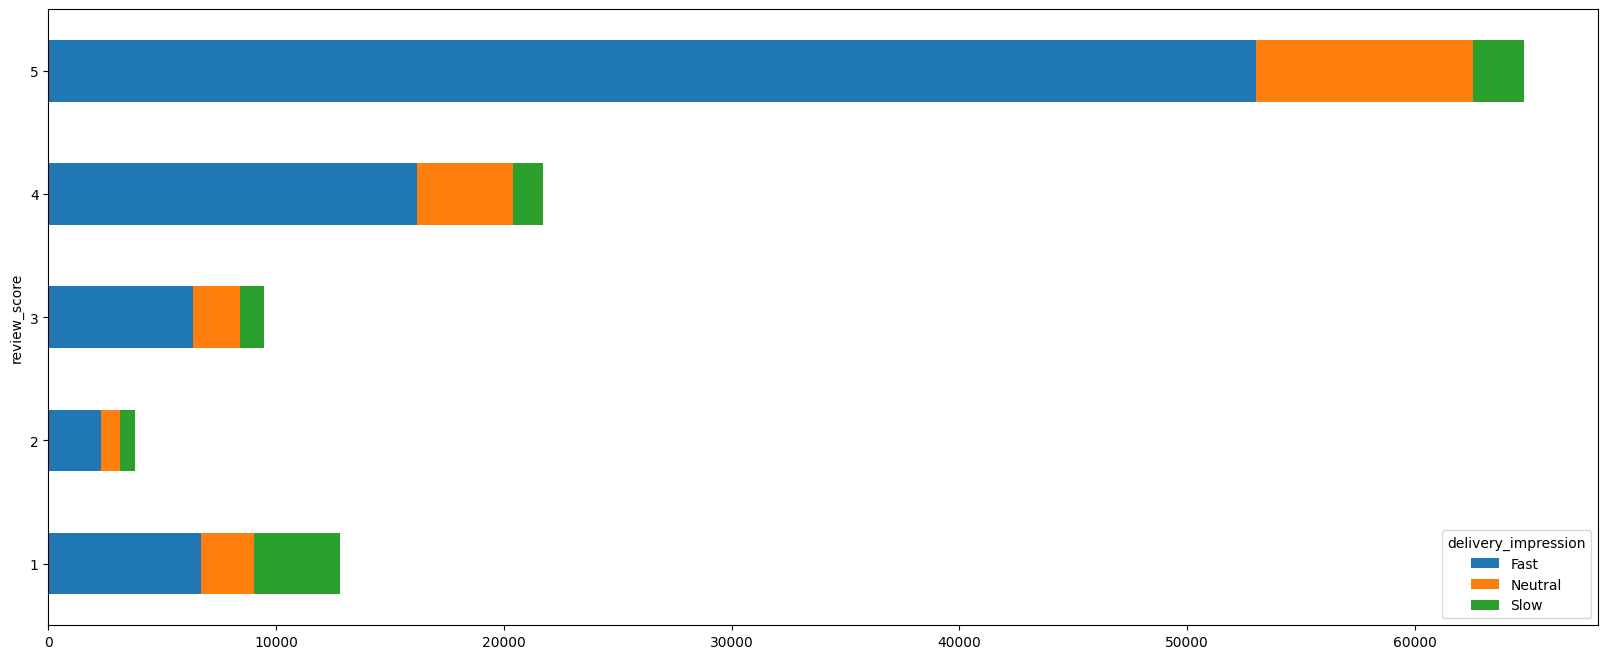

In [76]:
df_plot = data.groupby(['delivery_impression', 'review_score']).size().reset_index().pivot(columns='delivery_impression', index='review_score', values=0)
df_plot.plot(kind='barh',stacked=True,figsize=(20,8))
plt.show()

In [77]:
columns_to_drop = ['payment_type','order_status', 'order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','arrival_time',
                    'order_delivered_customer_date', "order_estimated_delivery_date",'review_creation_date','review_answer_timestamp',
                    'customer_unique_id','customer_city','customer_state','geolocation_city_customer', 'geolocation_state_customer','shipping_limit_date',
                    'product_id','seller_city', 'seller_state','geolocation_city_seller', 'geolocation_state_seller','order_id','customer_id',
                    'order_item_id', 'seller_id','product_category_name','review_time','delivery_impression', 'estimated_del_impression', 'ship_impression']

data_2 = data.copy()
data = data.drop(columns=columns_to_drop, axis=1)

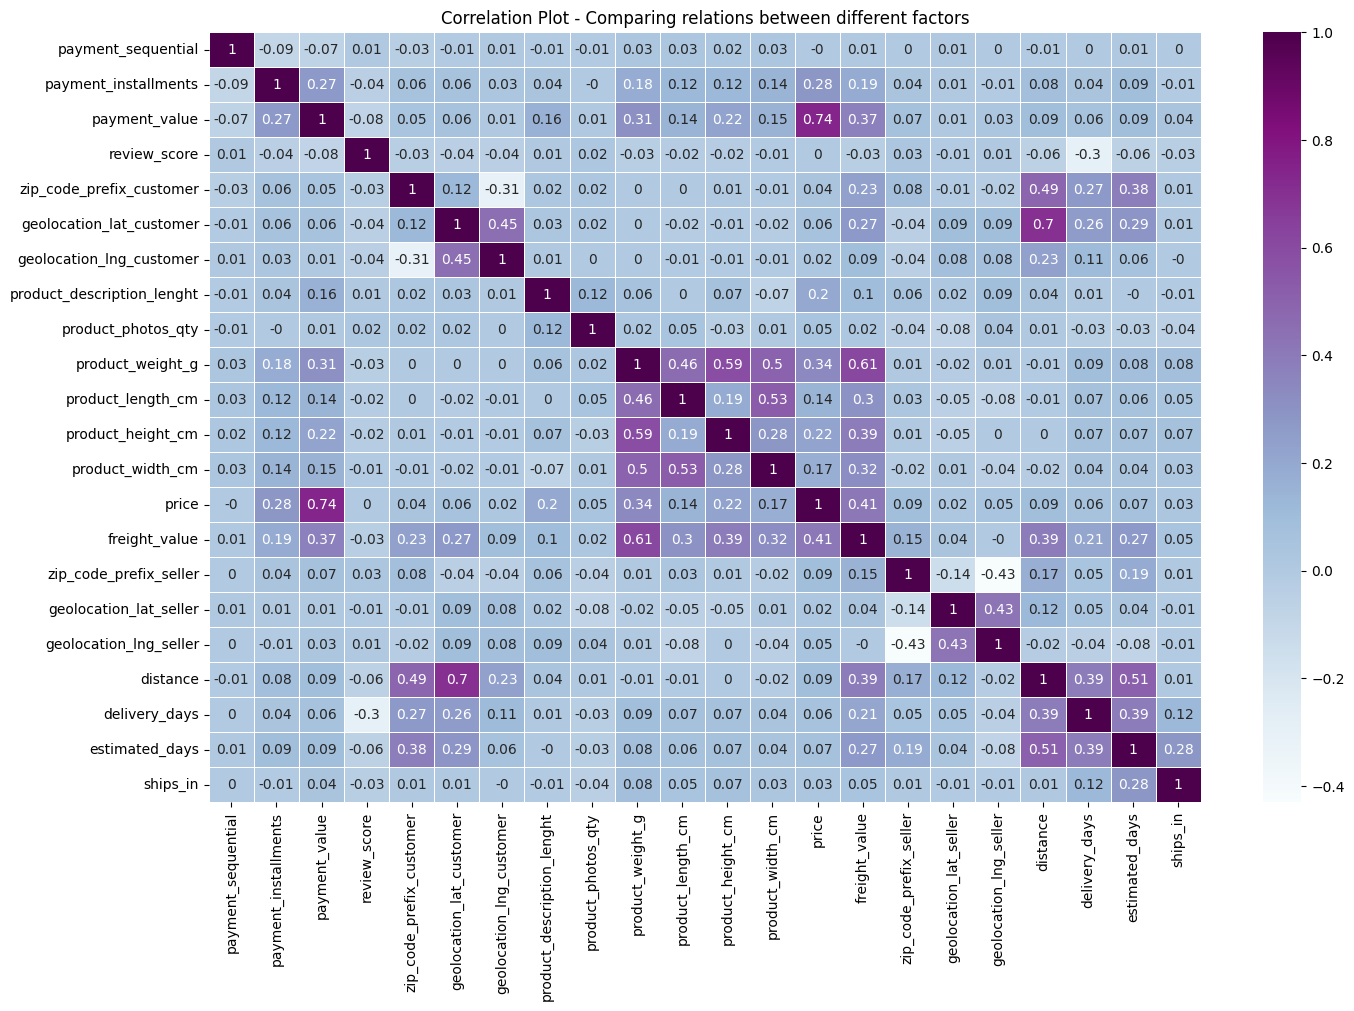

In [78]:
plt.figure(figsize=(16,10))
sns.heatmap(data.corr().round(2), annot = True, linewidths=0.5, linecolor="white", cmap='BuPu')
plt.title('Correlation Plot - Comparing relations between different factors')
plt.show()